Importing necessary libraries

In [14]:
from Datasets.CWRU import DataHelper
from DLModels.SISO.WDCNN.Original.Net import Net
from FitLoops.SISO import SimpleTrainer
from matplotlib import pyplot as plt
import numpy as np # type: ignore
import torch
import torch.nn as nn


Setting up experiment parameters

In [15]:
batch_size = 128    # size of mini-batches for training
epochs = 32       # number of complete passes through the training dataset
length = 2048     # sampling length
number = 1000     # number of samples per class
lr = 0.001        # learning rate
test_size = 0.3   # Testing data splited
sensors = ['DE']  # can contain DE=DriveEnd and FE=FanEnd
readRaw = ['RawData/0HP', 'RawData/1HP', 'RawData/2HP','RawData/3HP'] # read conditions data
normalizer = lambda x: (x - np.min(x)) / (np.max(x) - np.min(x)) # Normalize the data between 0 and 1 
save_model = "trained\\"  # path to trained model




Preproccessing the raw CWRU data, and creating Dataset

In [16]:

X = []
Y = []

for path in readRaw:
    raw = DataHelper.read_raw(path , sensors , normalizer)
    argumented_data = DataHelper.argumentation(raw, length=length, number = int(number / len(readRaw)), enc=False)
    Xtemp, Ytemp = DataHelper.add_label(argumented_data)
    if len(X) > 0:
        X = np.concatenate((X, Xtemp))
        Y = np.concatenate((Y, Ytemp))
    else:
        X = Xtemp
        Y = Ytemp

Y = DataHelper.one_hot(Y)

X_train, X_test, y_train, y_test = DataHelper.train_test_spliter(X,Y,test_size)

train_loader = DataHelper.get_torch_dataloder(X_train, y_train, batch_size=batch_size,shuffle=True)
test_loader = DataHelper.get_torch_dataloder(X_test, y_test, batch_size=batch_size,shuffle=True)


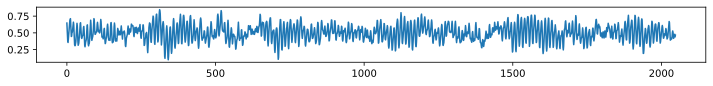

In [17]:


plt.figure(figsize=(12,1))
plt.plot(X[1][0])
plt.show()

loss 0.008, train acc 1.000, test acc 1.000


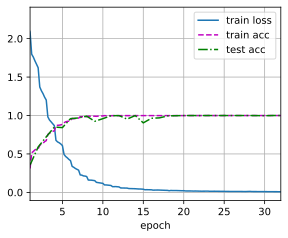

In [18]:

net = Net()
ps = filter(lambda x: x.requires_grad, net.parameters())
optimizer = torch.optim.SGD(ps, lr=lr, momentum=0.9, nesterov=True, weight_decay=1e-4)
loss = nn.CrossEntropyLoss()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu') 
SimpleTrainer.train(net , train_loader , test_loader , epochs, loss, optimizer, device)

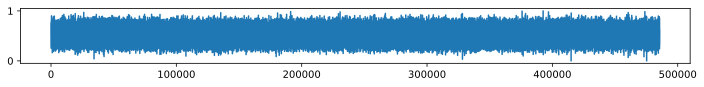

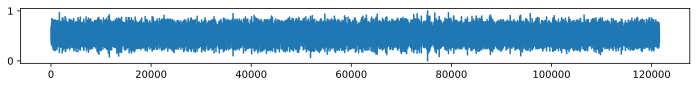

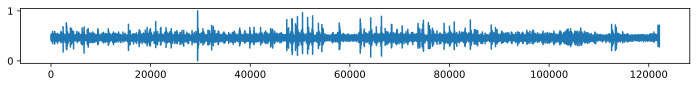

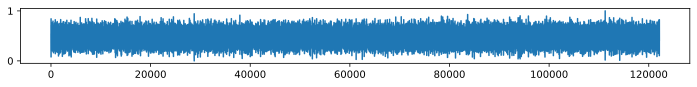

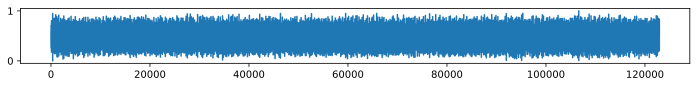

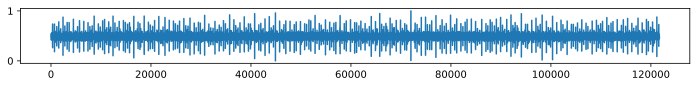

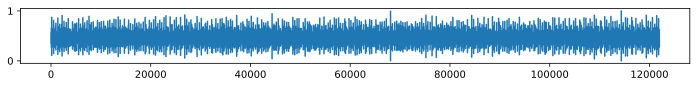

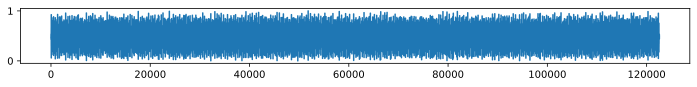

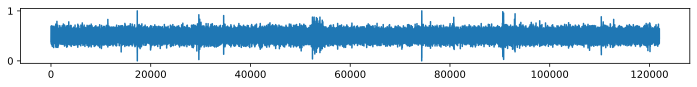

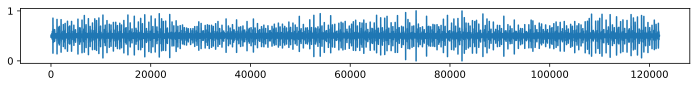

In [20]:
for i in raw:
    plt.figure(figsize=(12,1))
    # plt.title(i)
    plt.plot(raw[i][0])
    # plt.plot(raw[i][1])
    plt.show()